# BTNet American Put: Pricing, Greeks, and Weight Transfer

This notebook supports the VKR numerical experiments. It studies whether parameters learned by `BTNetEuropean` on Black-Scholes prices can be transferred into `BTNetAmerican` for American put pricing.

The theoretical basis is the BTNet representation of the CRR binomial tree from Shorokhov (2024). The notebook does not propose a new pricing method. It implements and checks the following numerical workflow:

1. Set a baseline market configuration.
2. Train `BTNetEuropean` on analytical Black-Scholes put prices.
3. Build two American models: one with analytical CRR weights and one with transferred European weights.
4. Compare both American models with QuantLib CRR(500), which is used as a numerical reference.
5. Repeat the pricing experiment for several volatility levels.
6. Compare Greeks obtained with analytical and transferred weights.
7. Export ONNX graphs for architecture visualization.

The central research question is whether European training gives a stable and financially meaningful initialization for the American put model.


In [1]:
import numpy as np
import torch
from btnn_bs import (
    BTNetEuropean,
    BTNetAmerican,
    train_BTNet,
    bs_put_price,
    plot_comparison,
    plot_errors,
    plot_training_losses,
    plot_prices_with_quantlib,
    plot_errors_vs_quantlib,
    run_quantlib_benchmark,
    error_stats,
    print_comparison_table,
)

## 1. Baseline Market Parameters

The baseline scenario matches the main experiment in the VKR: `S0 = 0.5`, `T = 1`, `r = 0.05`, `sigma = 0.25`, and BTNet depth `n_dim = 9`. Strikes are sampled in the interval `[0.25, 0.75]`.


In [2]:
S0  = 0.5
t0  = 0.0
T   = 1.0
r   = 0.05
sig = 0.25
n_dim = 9

# Training strikes: uniform sample
rng = np.random.default_rng(42)
K_train = rng.uniform(0.25, 0.75, size=200).astype(np.float32)
prices_train = np.array([bs_put_price(S0, K, T, r, sig) for K in K_train], dtype=np.float32)

# Test strikes: dense grid
K_test = np.linspace(0.25, 0.75, 100, dtype=np.float32)

print(f"n_dim={n_dim}, S0={S0}, T={T}, r={r}, sig={sig}")
print(f"Train samples: {len(K_train)}, Test grid: {len(K_test)}")


n_dim=9, S0=0.5, T=1.0, r=0.05, sig=0.25
Train samples: 200, Test grid: 100


## 2. Train the European BTNet

`BTNetEuropean` is trained on closed-form Black-Scholes put prices. The learned initial projection and convolution filter are later copied into the American architecture. This isolates the effect of weight transfer from any additional American-model training.


train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch [100/500], Loss: 0.000000
Epoch [200/500], Loss: 0.000000
Epoch [300/500], Loss: 0.000000
Epoch [400/500], Loss: 0.000000
Epoch [500/500], Loss: 0.000000


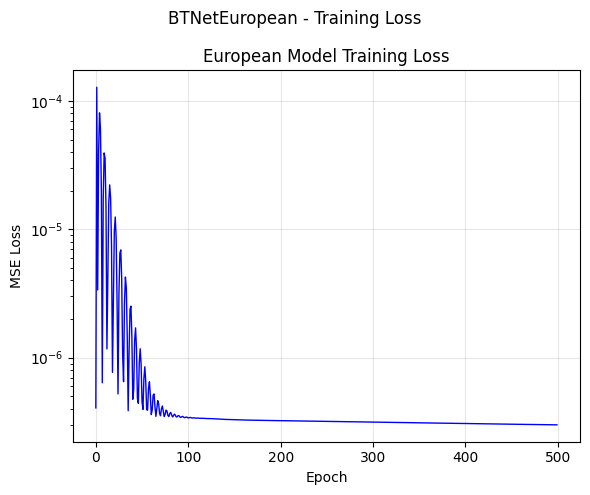

In [3]:
model_european = BTNetEuropean(n_dim, S0, sig, T, t0, r)

loss_hist_euro = train_BTNet(
    model_european,
    K_train,
    prices_train,
    epochs=500,
    lr=0.005,
    log_every=100,
)

plot_training_losses(loss_hist_euro, title="BTNetEuropean - Training Loss")


## 3. Construct the Transferred American Model

A fresh `BTNetAmerican` is created, then the shared parameters `(w^n, b^n, W)` are copied from the trained European model. The maxout structure remains the American one, so early exercise is still represented by the American architecture. No further training is performed after the transfer.


In [4]:
model_amer_transfer = BTNetAmerican(n_dim, S0, sig, T, t0, r)

with torch.no_grad():
    # Transfer w^n and b^n from the initial projection layer
    model_amer_transfer._initial_layer._linear.weight.data.copy_(
        model_european._initial_layer._linear.weight.data
    )
    model_amer_transfer._initial_layer._linear.bias.data.copy_(
        model_european._initial_layer._linear.bias.data
    )

    # Transfer W into every MaxoutLayer convolution branch
    euro_W = model_european._conv_layer._conv_1d.weight.data  # shape (1, 1, 2)
    for maxout_layer in model_amer_transfer._maxout_layers:
        maxout_layer._conv_1d.weight.data.copy_(euro_W)

# Freeze all parameters after transfer
for p in model_amer_transfer.parameters():
    p.requires_grad_(False)
model_amer_transfer.eval()

print("Transferred W:", euro_W.squeeze().tolist())
print("Parameters frozen:", all(not p.requires_grad for p in model_amer_transfer.parameters()))


Transferred W: [0.4889150559902191, 0.5063319802284241]
Parameters frozen: True


## 4. Construct the Analytical American Baseline

This model uses the analytical CRR initialization from the BTNet construction. It is the main baseline because its weights have a direct risk-neutral interpretation.


In [5]:
model_amer_analytical = BTNetAmerican(n_dim, S0, sig, T, t0, r)

for p in model_amer_analytical.parameters():
    p.requires_grad_(False)
model_amer_analytical.eval()

analytical_W = model_amer_analytical._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()
print("Analytical W:", analytical_W)

Analytical W: [0.48473337292671204, 0.5097264647483826]


## 5. QuantLib Numerical Reference

QuantLib CRR with 500 time steps is used as a high-resolution numerical reference for American put prices. It is not treated as a closed-form exact solution.


In [6]:
ql_result = run_quantlib_benchmark(
    S0, K_test, T, r, sig, amer_crr_steps=500
)
ql_prices = ql_result.ql_american_crr  # numpy array of American CRR put prices

print(f"QuantLib prices computed: {len(ql_prices)} values, "
      f"range [{ql_prices.min():.4f}, {ql_prices.max():.4f}]")


QuantLib prices computed: 100 values, range [0.0000, 0.2500]


## 6. Baseline Pricing Comparison

The two American BTNet variants are evaluated on the same strike grid and compared with the QuantLib CRR(500) reference.


In [7]:
K_test_t = torch.from_numpy(K_test).float().unsqueeze(1)

with torch.no_grad():
    pred_transfer   = model_amer_transfer.predict(K_test_t).flatten()
    pred_analytical = model_amer_analytical.predict(K_test_t).flatten()

stats_transfer   = error_stats(pred_transfer,   ql_prices)
stats_analytical = error_stats(pred_analytical, ql_prices)

print_comparison_table(
    american={
        "Transferred W": stats_transfer,
        "Analytical W":  stats_analytical,
    }
)

American put — errors vs QuantLib (CRR tree)
  Transferred W           MAE=4.38e-04  RMSE=6.81e-04  max|.|=1.71e-03
  Analytical W            MAE=2.84e-04  RMSE=4.06e-04  max|.|=1.10e-03


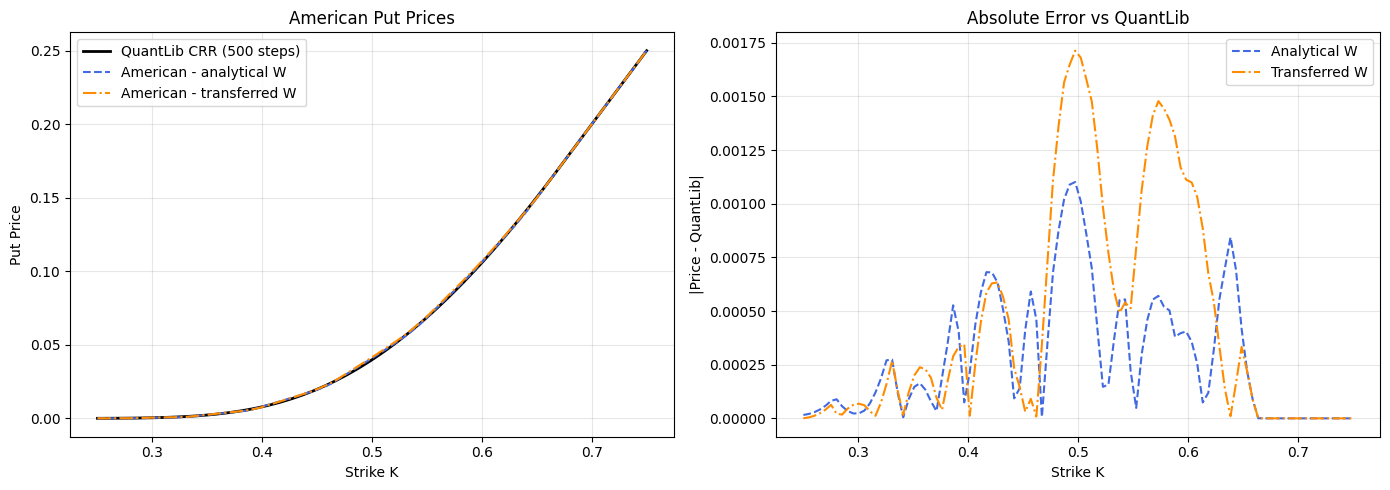

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price curves
axes[0].plot(K_test, ql_prices,        label="QuantLib CRR (500 steps)", lw=2, color="black")
axes[0].plot(K_test, pred_analytical,  label="American - analytical W",   lw=1.5, linestyle="--", color="royalblue")
axes[0].plot(K_test, pred_transfer,    label="American - transferred W",  lw=1.5, linestyle="-.", color="darkorange")
axes[0].set_xlabel("Strike K")
axes[0].set_ylabel("Put Price")
axes[0].set_title("American Put Prices")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: absolute errors vs QuantLib
err_analytical = np.abs(pred_analytical - ql_prices)
err_transfer   = np.abs(pred_transfer   - ql_prices)

axes[1].plot(K_test, err_analytical, label="Analytical W",  lw=1.5, linestyle="--", color="royalblue")
axes[1].plot(K_test, err_transfer,   label="Transferred W", lw=1.5, linestyle="-.", color="darkorange")
axes[1].set_xlabel("Strike K")
axes[1].set_ylabel("|Price - QuantLib|")
axes[1].set_title("Absolute Error vs QuantLib")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Baseline Result

In the baseline scenario (`sigma = 0.25`), the analytical American model is closer to the QuantLib CRR(500) reference than the transferred model.

| Model | MAE | RMSE | max\|err\| |
|---|---:|---:|---:|
| `BTNetAmerican`, analytical `W` | **2.84e-4** | **4.06e-4** | **1.10e-3** |
| `BTNetAmerican`, transferred `W` | 4.38e-4 | 6.81e-4 | 1.71e-3 |

The learned European filter is close to the analytical CRR filter, but not identical:

| Filter | Values |
|---|---|
| Analytical `W` | `[0.4847, 0.5097]` |
| Transferred `W` | `[0.4889, 0.5063]` |

The difference is small in absolute terms, yet it changes the continuation value at every backward-induction layer. In the baseline experiment this is enough to increase all three pricing-error metrics.

The interpretation is deliberately limited: this does not prove that transfer is always worse for every market regime. It shows that European training does not automatically recover the American risk-neutral weights required by the maxout recursion.


## 8. Reusable Scenario Function

The helper below repeats the full experiment for a chosen volatility: train the European model, transfer its weights into the American model, build the analytical American baseline, compute QuantLib CRR(500) prices, and return prices, errors, weights, and summary metrics.


In [9]:
def run_transfer_pricing_scenario(sig_value, seed=42):
    """Run the complete European-to-American transfer experiment for one volatility."""
    S0_s, t0_s, T_s, r_s, n_s = 0.5, 0.0, 1.0, 0.05, 9
    rng_s = np.random.default_rng(seed)

    K_train_s = rng_s.uniform(0.25, 0.75, size=200).astype(np.float32)
    prices_train_s = np.array(
        [bs_put_price(S0_s, K, T_s, r_s, sig_value) for K in K_train_s],
        dtype=np.float32,
    )
    K_test_s = np.linspace(0.25, 0.75, 100, dtype=np.float32)

    torch.manual_seed(seed)
    model_euro_s = BTNetEuropean(n_s, S0_s, sig_value, T_s, t0_s, r_s)
    loss_hist_s = train_BTNet(
        model_euro_s,
        K_train_s,
        prices_train_s,
        epochs=500,
        lr=0.005,
        log_every=0,
    )

    model_transfer_s = BTNetAmerican(n_s, S0_s, sig_value, T_s, t0_s, r_s)
    with torch.no_grad():
        model_transfer_s._initial_layer._linear.weight.data.copy_(
            model_euro_s._initial_layer._linear.weight.data
        )
        model_transfer_s._initial_layer._linear.bias.data.copy_(
            model_euro_s._initial_layer._linear.bias.data
        )
        euro_W_s = model_euro_s._conv_layer._conv_1d.weight.data
        for maxout_layer in model_transfer_s._maxout_layers:
            maxout_layer._conv_1d.weight.data.copy_(euro_W_s)
    for p in model_transfer_s.parameters():
        p.requires_grad_(False)
    model_transfer_s.eval()

    model_analytical_s = BTNetAmerican(n_s, S0_s, sig_value, T_s, t0_s, r_s)
    for p in model_analytical_s.parameters():
        p.requires_grad_(False)
    model_analytical_s.eval()

    ql_s = run_quantlib_benchmark(S0_s, K_test_s, T_s, r_s, sig_value, amer_crr_steps=500)
    ql_prices_s = ql_s.ql_american_crr
    K_test_t_s = torch.from_numpy(K_test_s).float().unsqueeze(1)
    with torch.no_grad():
        prices_analytical_s = model_analytical_s.predict(K_test_t_s).flatten()
        prices_transfer_s = model_transfer_s.predict(K_test_t_s).flatten()

    err_analytical_s = np.abs(prices_analytical_s - ql_prices_s)
    err_transfer_s = np.abs(prices_transfer_s - ql_prices_s)

    return {
        "sigma": sig_value,
        "K_test": K_test_s,
        "ql_prices": ql_prices_s,
        "prices_analytical": prices_analytical_s,
        "prices_transfer": prices_transfer_s,
        "err_analytical": err_analytical_s,
        "err_transfer": err_transfer_s,
        "final_loss": float(loss_hist_s[-1]),
        "W_analytical": model_analytical_s._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist(),
        "W_transfer": model_transfer_s._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist(),
        "stats_analytical": error_stats(prices_analytical_s, ql_prices_s),
        "stats_transfer": error_stats(prices_transfer_s, ql_prices_s),
    }


## 9. Volatility Sweep

The experiment is repeated for `sigma` values `0.10`, `0.25`, `0.60`, and `0.90`. This checks whether the conclusion about transferred weights is stable across market regimes.

The sweep supports a more careful conclusion than the baseline alone. Transfer is almost neutral at low volatility, worse in the baseline scenario, slightly better for `sigma = 0.60` in price metrics, and materially worse for `sigma = 0.90`. Therefore, transfer should be treated as a parameter-sensitive heuristic rather than a reliable initialization rule.


In [10]:
SIGMA_SWEEP_VALUES = [0.10, 0.25, 0.60, 0.90]

sigma_sweep_results = [
    run_transfer_pricing_scenario(sig_value)
    for sig_value in SIGMA_SWEEP_VALUES
]

print("sigma | variant      | MAE       | RMSE      | max|err|")
print("------|--------------|-----------|-----------|----------")
for result in sigma_sweep_results:
    for label, stats_key in [
        ("analytical", "stats_analytical"),
        ("transfer", "stats_transfer"),
    ]:
        stats = result[stats_key]
        print(
            f"{result['sigma']:<5.2f} | {label:<12} | "
            f"{stats['mae']:.3e} | {stats['rmse']:.3e} | {stats['max_abs']:.3e}"
        )


train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

sigma | variant      | MAE       | RMSE      | max|err|
------|--------------|-----------|-----------|----------
0.10  | analytical   | 2.656e-05 | 7.085e-05 | 3.663e-04
0.10  | transfer     | 2.618e-05 | 7.063e-05 | 3.675e-04
0.25  | analytical   | 2.843e-04 | 4.062e-04 | 1.101e-03
0.25  | transfer     | 4.379e-04 | 6.810e-04 | 1.713e-03
0.60  | analytical   | 1.468e-03 | 1.685e-03 | 2.974e-03
0.60  | transfer     | 1.238e-03 | 1.497e-03 | 2.784e-03
0.90  | analytical   | 2.057e-03 | 2.392e-03 | 4.230e-03
0.90  | transfer     | 5.792e-03 | 6.344e-03 | 1.230e-02


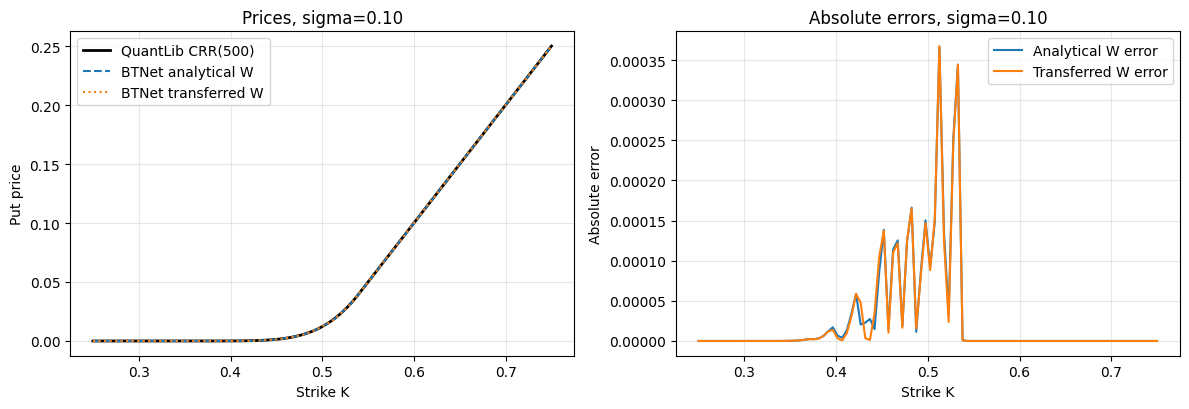

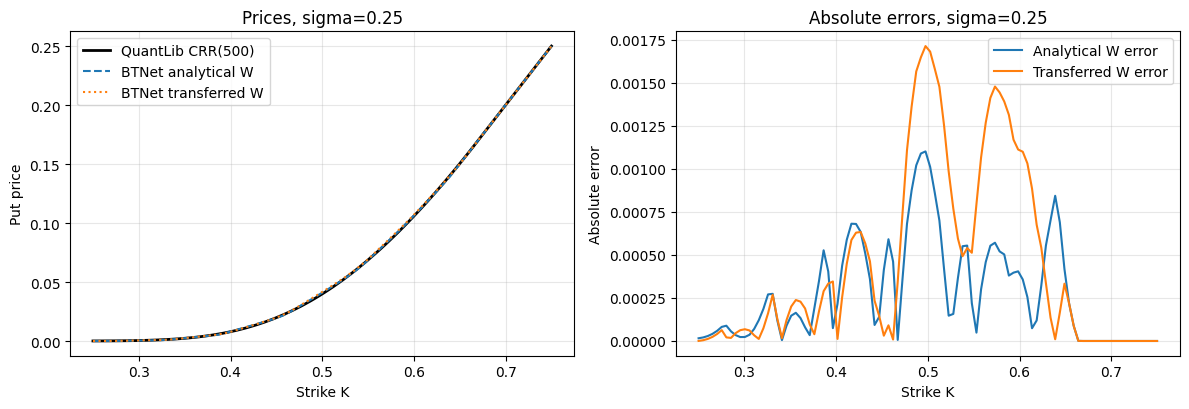

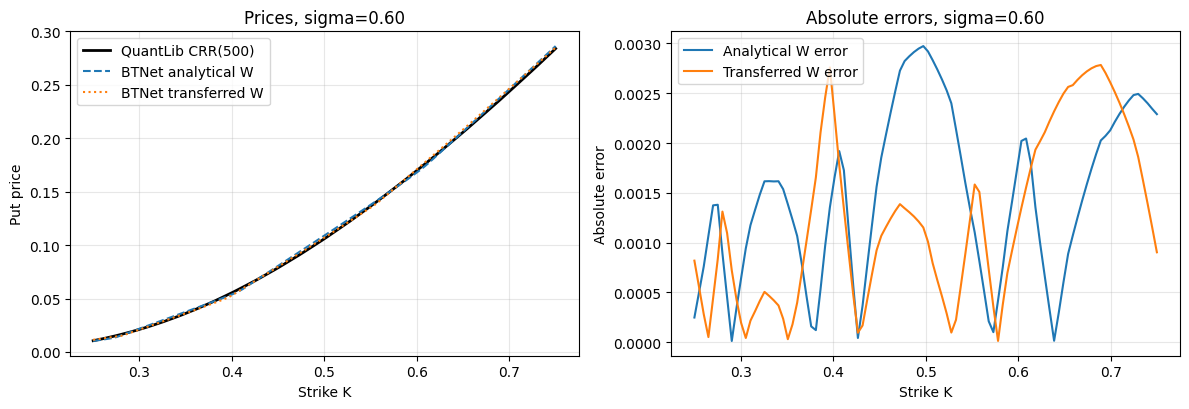

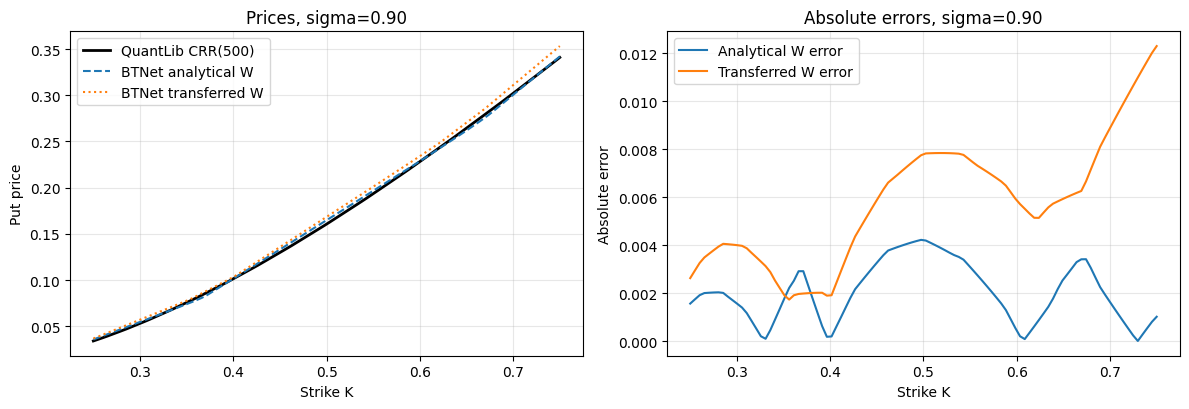

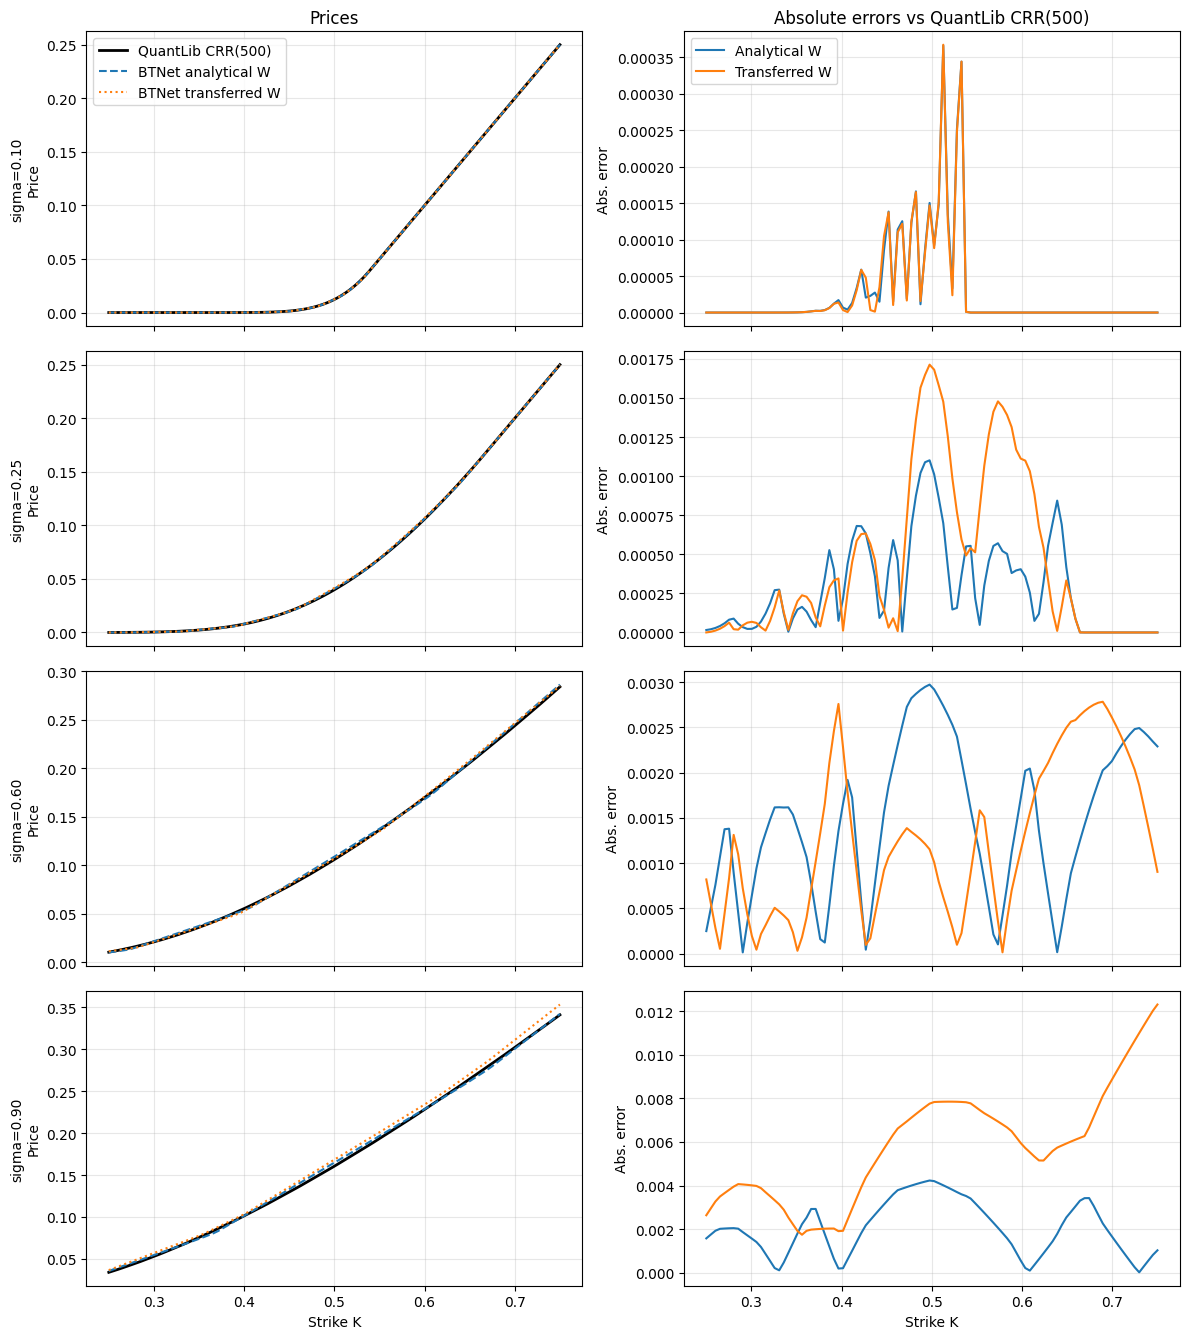

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("FinalQualifyingWork/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

for result in sigma_sweep_results:
    sigma = result["sigma"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].plot(result["K_test"], result["ql_prices"], label="QuantLib CRR(500)", color="black", linewidth=2)
    axes[0].plot(result["K_test"], result["prices_analytical"], "--", label="BTNet analytical W")
    axes[0].plot(result["K_test"], result["prices_transfer"], ":", label="BTNet transferred W")
    axes[0].set_title(f"Prices, sigma={sigma:.2f}")
    axes[0].set_xlabel("Strike K")
    axes[0].set_ylabel("Put price")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(result["K_test"], result["err_analytical"], label="Analytical W error")
    axes[1].plot(result["K_test"], result["err_transfer"], label="Transferred W error")
    axes[1].set_title(f"Absolute errors, sigma={sigma:.2f}")
    axes[1].set_xlabel("Strike K")
    axes[1].set_ylabel("Absolute error")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig_3_2_sigma_{str(sigma).replace('.', '_')}_prices_errors.png", dpi=200)
    plt.show()

fig, axes = plt.subplots(len(sigma_sweep_results), 2, figsize=(12, 13.5), sharex=True)
for row, result in enumerate(sigma_sweep_results):
    sigma = result["sigma"]
    axes[row, 0].plot(result["K_test"], result["ql_prices"], label="QuantLib CRR(500)", color="black", linewidth=2)
    axes[row, 0].plot(result["K_test"], result["prices_analytical"], "--", label="BTNet analytical W")
    axes[row, 0].plot(result["K_test"], result["prices_transfer"], ":", label="BTNet transferred W")
    axes[row, 0].set_ylabel(f"sigma={sigma:.2f}\nPrice")
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(result["K_test"], result["err_analytical"], label="Analytical W")
    axes[row, 1].plot(result["K_test"], result["err_transfer"], label="Transferred W")
    axes[row, 1].set_ylabel("Abs. error")
    axes[row, 1].grid(True, alpha=0.3)

axes[0, 0].set_title("Prices")
axes[0, 1].set_title("Absolute errors vs QuantLib CRR(500)")
axes[-1, 0].set_xlabel("Strike K")
axes[-1, 1].set_xlabel("Strike K")
axes[0, 0].legend(loc="upper left")
axes[0, 1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_2_sigma_sweep_prices_errors.png", dpi=200)
plt.show()



## 10. Greeks: Analytical vs Transferred Weights

After the pricing comparison, the next question is whether transferred weights distort local sensitivities.

The calculation uses `btnet_american_greeks_fixed_W`, a differentiable CRR/BTNet pass where `W` is fixed externally. This matches the inference-time behavior of the analytical and transferred American models in this notebook.

Two consequences are important:

- `Delta` changes because the backward induction uses different continuation weights.
- `Vega` and `Theta` are structurally incomplete when `W` is fixed, because the indirect dependence of risk-neutral probabilities on `sigma` and `T` is removed.

The Black-Scholes European Greeks are plotted only as a visual reference. They are not exact benchmarks for American put Greeks.


In [12]:
from btnn_bs import (
    btnet_american_greeks_fixed_W,
    bs_greeks,
    plot_american_greeks_transfer,
    plot_american_greeks_transfer_errors,
)

### 10.1 Extract Filters


In [13]:
# Analytical model: W from the MaxoutLayer convolution filter
W_analytical = model_amer_analytical._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()

# Transferred model: W copied from the trained European model
W_transfer = model_amer_transfer._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()

print(f"Analytical W : {[round(w,6) for w in W_analytical]}")
print(f"Transferred W: {[round(w,6) for w in W_transfer]}")
print(f"\nDelta W (transferred - analytical): {[round(W_transfer[i]-W_analytical[i],6) for i in range(2)]}")
print(f"Sum W (should = exp(-r*dt) = {np.exp(-r*(T/n_dim)):.6f}):")
print(f"  analytical  sum = {sum(W_analytical):.6f}")
print(f"  transferred sum = {sum(W_transfer):.6f}")


Analytical W : [0.484733, 0.509726]
Transferred W: [0.488915, 0.506332]

Delta W (transferred - analytical): [0.004182, -0.003394]
Sum W (should = exp(-r*dt) = 0.994460):
  analytical  sum = 0.994460
  transferred sum = 0.995247


### 10.2 Compute Greeks


In [14]:
# Greeks with analytical W (Theorem 2 risk-neutral weights)
greeks_analytical_W = btnet_american_greeks_fixed_W(
    K_test, S0, sig, T,
    W0_val=W_analytical[0], W1_val=W_analytical[1],
    n=n_dim,
)

# Greeks with transferred W (European-trained weights)
greeks_transfer_W = btnet_american_greeks_fixed_W(
    K_test, S0, sig, T,
    W0_val=W_transfer[0], W1_val=W_transfer[1],
    n=n_dim,
)

# Black-Scholes European Greeks, used only as a visual reference
greeks_bs = bs_greeks(K_test, S0, sig, r, T)

print("Greeks computed for both W variants.")


Greeks computed for both W variants.


### 10.3 Greek Differences


In [15]:
import numpy as np

print(f"{'Greek':<8} {'MAE':>12} {'Max |diff|':>12}")
print("-" * 34)
for key in ("delta", "gamma", "vega", "theta"):
    diff = np.abs(greeks_analytical_W[key] - greeks_transfer_W[key])
    print(f"{key.capitalize():<8} {diff.mean():>12.6f} {diff.max():>12.6f}")

Greek             MAE   Max |diff|
----------------------------------
Delta        0.007924     0.092501
Gamma        0.000000     0.000000
Vega         0.003306     0.036529
Theta        0.000413     0.004566


### 10.4 Plot Greek Curves


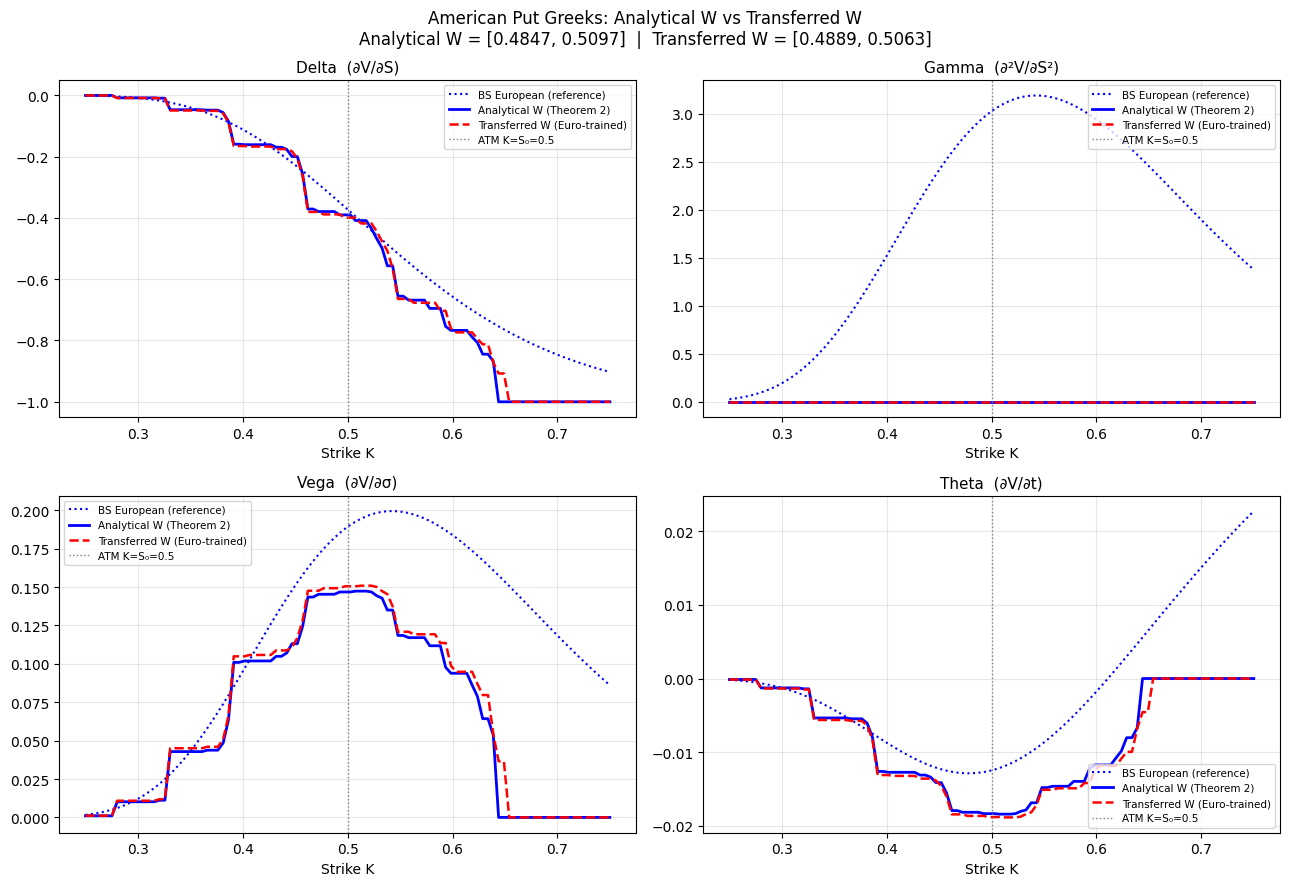

In [16]:
plot_american_greeks_transfer(
    K_test,
    greeks_analytical_W,
    greeks_transfer_W,
    greeks_bs,
    S0=S0,
    W_analytical=W_analytical,
    W_transfer=W_transfer,
)

### 10.5 Plot Absolute Greek Differences


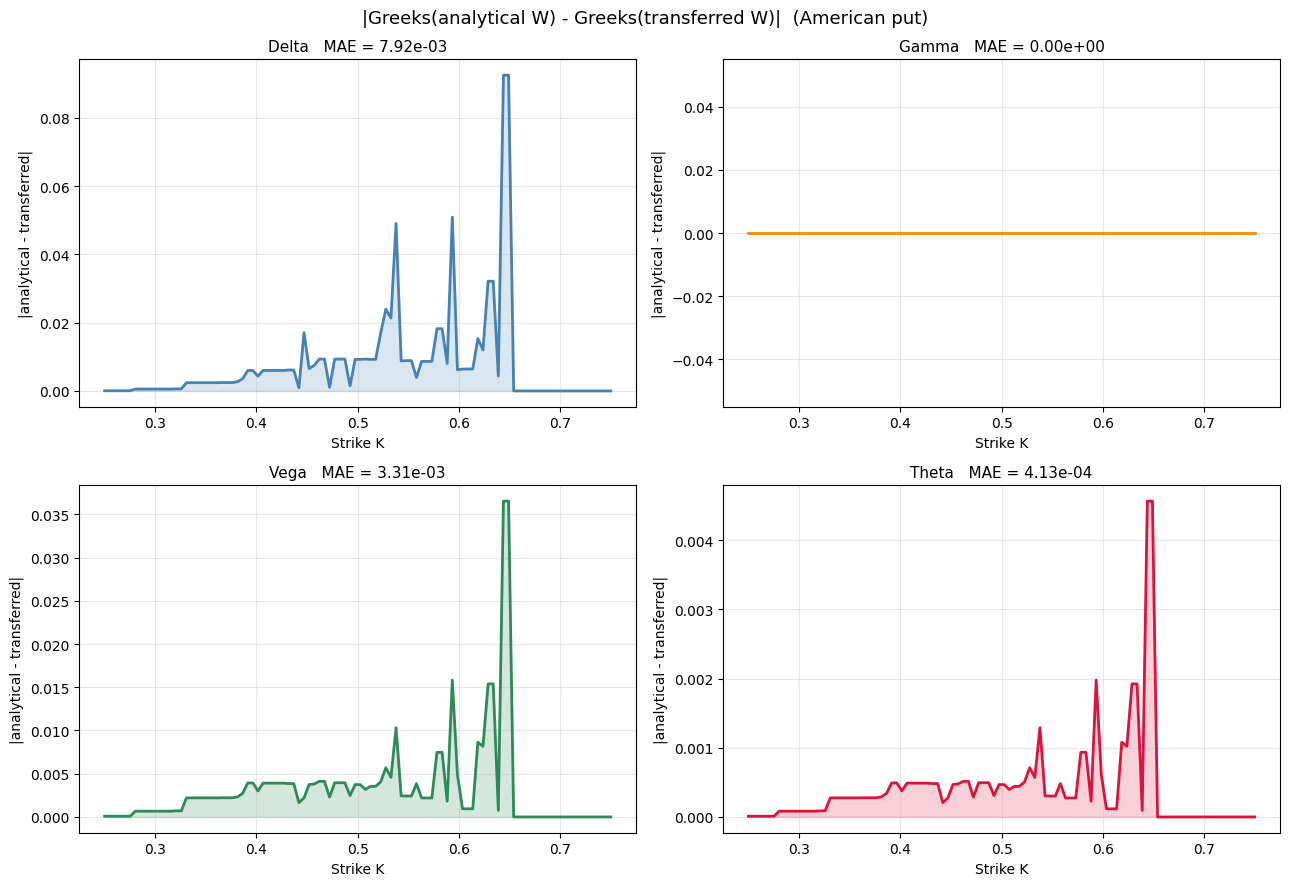

In [17]:
plot_american_greeks_transfer_errors(
    K_test,
    greeks_analytical_W,
    greeks_transfer_W,
)

### 10.6 Interpretation

The two filters differ by about `0.004` per component in the baseline scenario, but the Greeks still diverge visibly.

| Greek | Interpretation |
|---|---|
| `Delta` | Changes because continuation values are reweighted across the tree. |
| `Gamma` | Equal to zero almost everywhere for both variants because ReLU/maxout makes the model piecewise linear. |
| `Vega` | Sensitive to the missing indirect channel `sigma -> W`; fixed-weight Greeks should be interpreted cautiously. |
| `Theta` | Also affected by the missing dependence of `W` on time step size. |

The main negative result is the behavior of `Gamma`. A piecewise-linear BTNet can be useful for illustrating differentiable pricing and for studying first-order sensitivities, but it is not a complete risk-management tool when convexity risk is important. In particular, delta-gamma hedging based on this `Gamma` would be misleading without smoothing the architecture, for example by replacing hard maxout with a smooth approximation.


## 11. ONNX Export

The trained European model and both American variants are exported to ONNX for architecture inspection in Netron and for possible inclusion in the VKR appendix. These exports are for visualization, not for additional calibration.


In [18]:
import os

ONNX_DIR = "onnx_exports"
os.makedirs(ONNX_DIR, exist_ok=True)

# Representative input: single strike at ATM (batch_size=1)
dummy_K = torch.tensor([[S0]], dtype=torch.float32)

# BTNetEuropean
model_european.eval()
path_eu = os.path.join(ONNX_DIR, "btnet_european.onnx")
torch.onnx.export(
    model_european,
    dummy_K,
    path_eu,
    input_names=["strike"],
    output_names=["price"],
    dynamic_axes={"strike": {0: "batch_size"}, "price": {0: "batch_size"}},
    opset_version=17,
)
print(f"Exported BTNetEuropean            -> {path_eu}")

# BTNetAmerican with analytical CRR weights
model_amer_analytical.eval()
path_am_an = os.path.join(ONNX_DIR, "btnet_american_analytical.onnx")
torch.onnx.export(
    model_amer_analytical,
    dummy_K,
    path_am_an,
    input_names=["strike"],
    output_names=["price"],
    dynamic_axes={"strike": {0: "batch_size"}, "price": {0: "batch_size"}},
    opset_version=17,
)
print(f"Exported BTNetAmerican (analytical) -> {path_am_an}")

# BTNetAmerican with transferred European weights
model_amer_transfer.eval()
path_am_tr = os.path.join(ONNX_DIR, "btnet_american_transfer.onnx")
torch.onnx.export(
    model_amer_transfer,
    dummy_K,
    path_am_tr,
    input_names=["strike"],
    output_names=["price"],
    dynamic_axes={"strike": {0: "batch_size"}, "price": {0: "batch_size"}},
    opset_version=17,
)
print(f"Exported BTNetAmerican (transfer)   -> {path_am_tr}")


/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_76946/4084331730.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0511 00:34:25.504000 76946 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0511 00:34:25.768000 76946 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0511 00:34:25.769000 76946 torch/onnx/_in

[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_76946/4084331730.py:26: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0511 00:34:26.404000 76946 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may 

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported BTNetEuropean            -> onnx_exports/btnet_european.onnx
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_76946/4084331730.py:40: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0511 00:34:26.889000 76946 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may 

[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported BTNetAmerican (analytical) -> onnx_exports/btnet_american_analytical.onnx


W0511 00:34:27.059000 76946 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0511 00:34:27.059000 76946 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0511 00:34:27.060000 76946 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported BTNetAmerican (transfer)   -> onnx_exports/btnet_american_transfer.onnx


In [19]:
# Verify exported files
print(f"{'File':<45} {'Size':>8}")
print("-" * 55)
for fname in sorted(os.listdir(ONNX_DIR)):
    path = os.path.join(ONNX_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {fname:<43} {size_kb:6.1f} KB")

File                                              Size
-------------------------------------------------------
  btnet_american_analytical.onnx                 9.5 KB
  btnet_american_analytical.onnx.data            0.0 KB
  btnet_american_transfer.onnx                   9.5 KB
  btnet_american_transfer.onnx.data              0.0 KB
  btnet_european.onnx                            5.0 KB
  btnet_european.onnx.data                       0.0 KB
